In [ ]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet
!pip install --upgrade scipy statsmodels
!pip install ctgan

In [31]:
import os 
import sys
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings


sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.imputation as imp
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

In [32]:
df = imp.load_data("bd_labs_imputed_within_2yrs.csv")
# Standardize the 'PerformedDate' by converting it to a 'VisitOrder' variable, grouping by patient and ordering their lab test records chronologically
df = df.sort_values(['Patient_ID', 'PerformedDate'])

Loaded dataset with shape: (318, 12)


In [33]:
df['Sex'] = df['Sex'].astype('category')
df['BD_Code'] = df['BD_Code'].astype('category')
df['Comorbidity'] = df['Comorbidity'].astype('category')

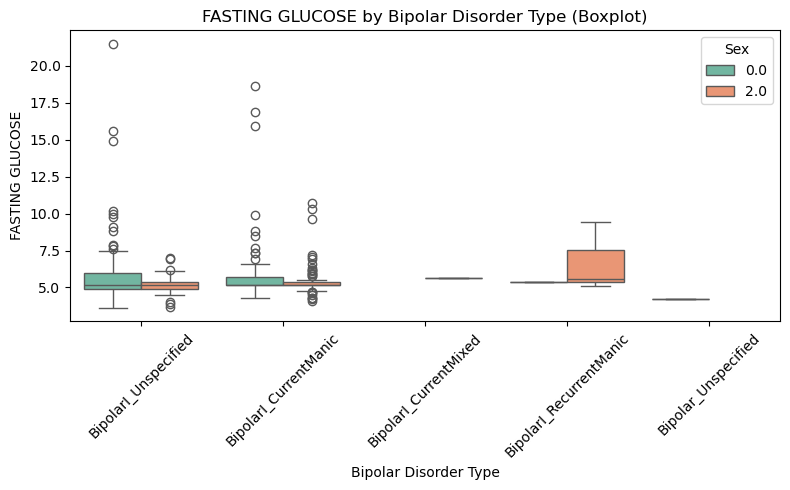

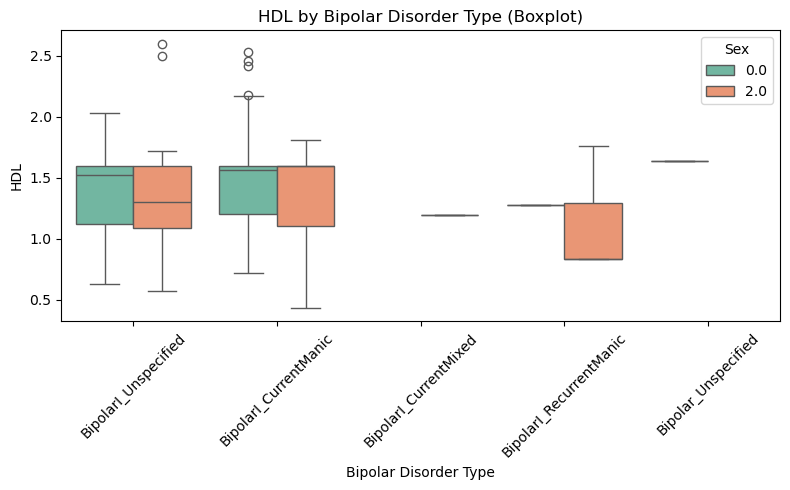

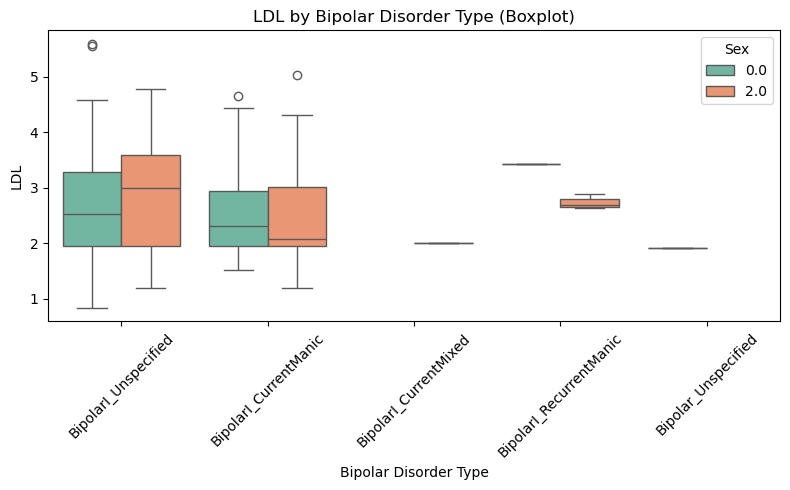

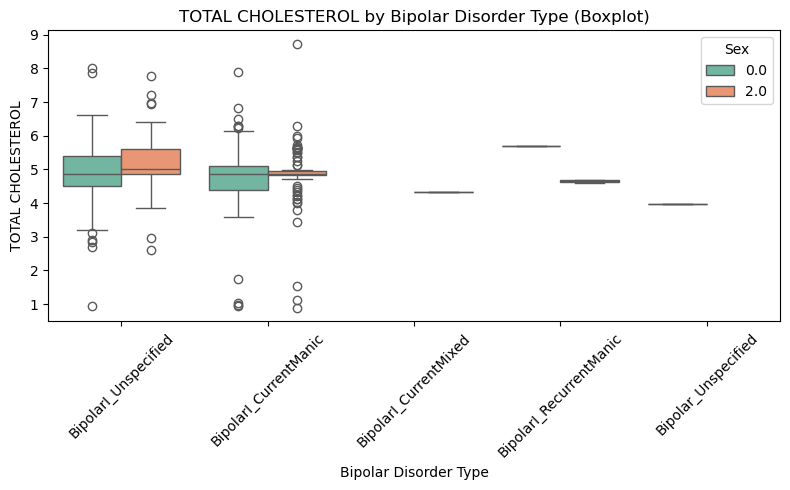

In [34]:
# Map and encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)

em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='Bipolar Disorder Type',plot_type='box', hue="Sex")

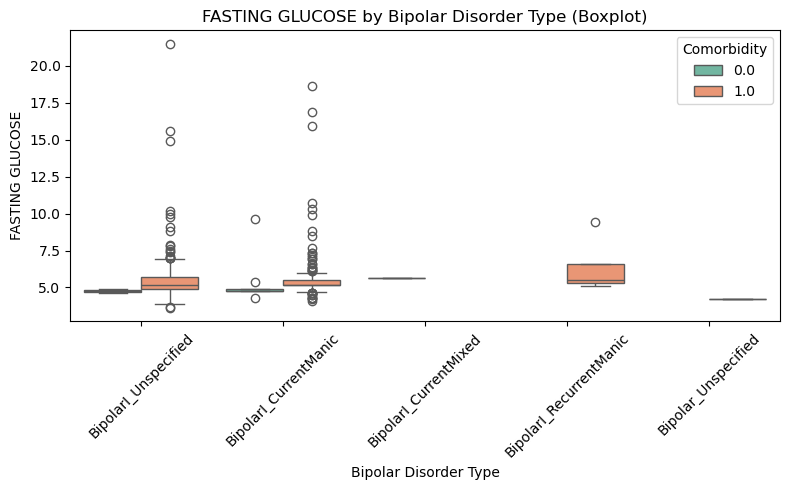

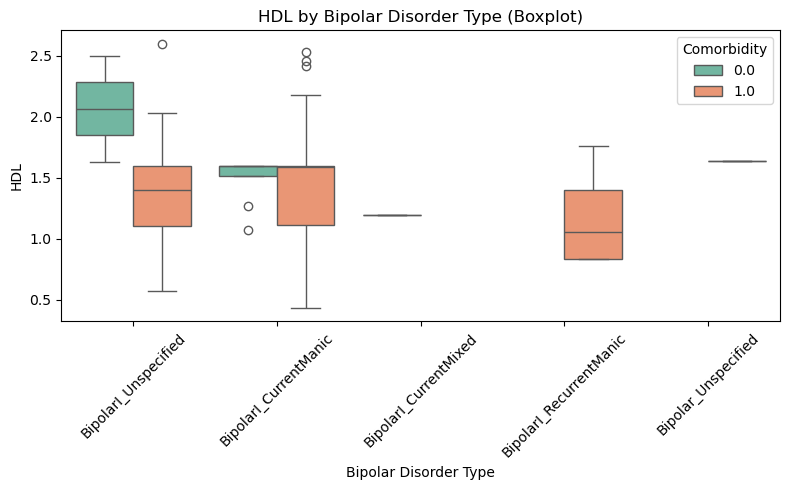

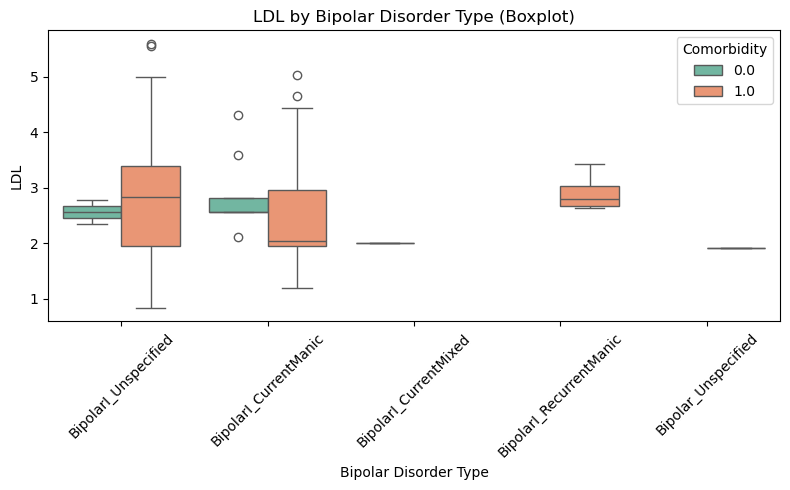

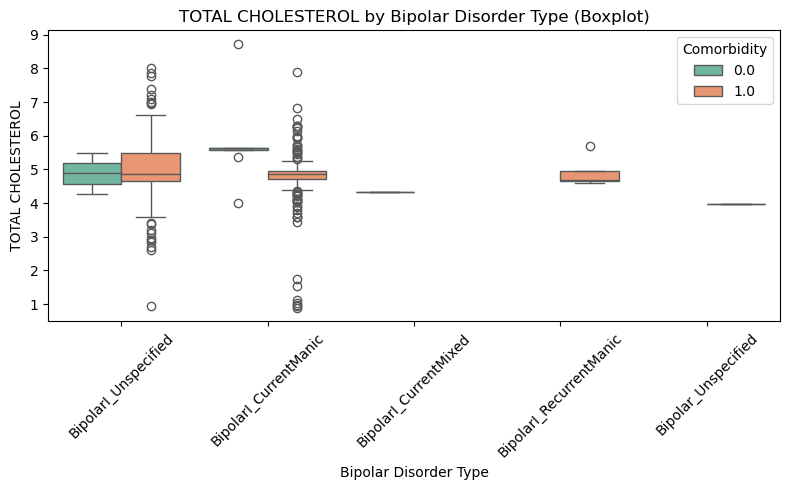

In [35]:
# EDA group by Comorbidity
em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='Bipolar Disorder Type',plot_type='box', hue="Comorbidity")

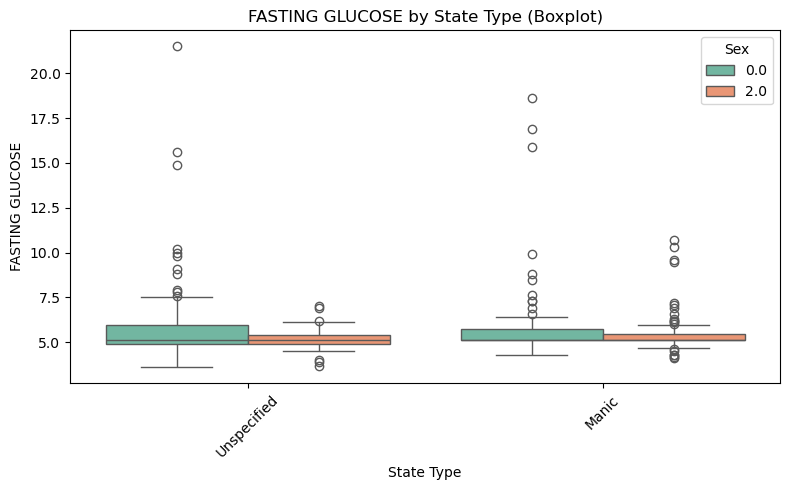

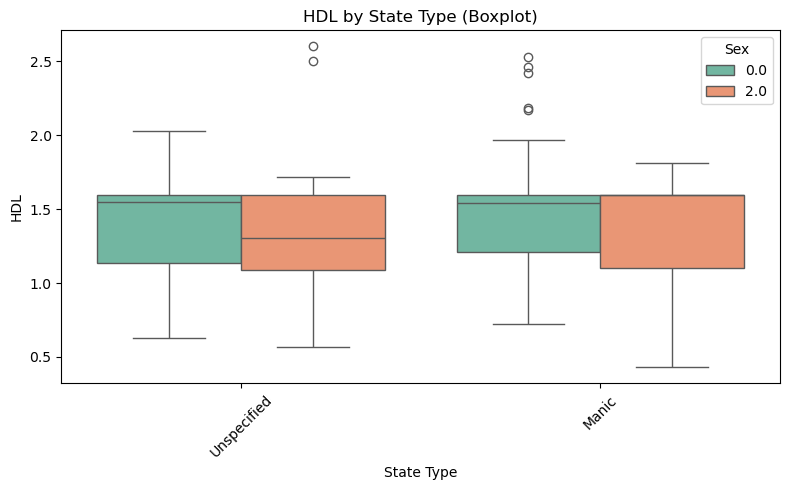

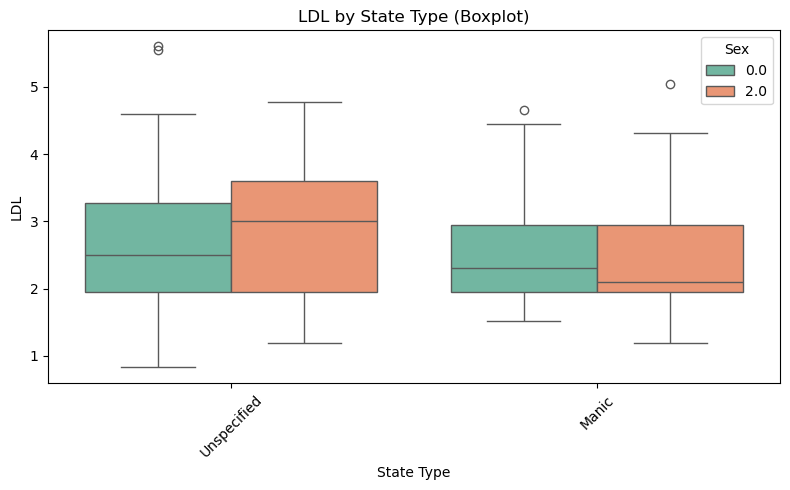

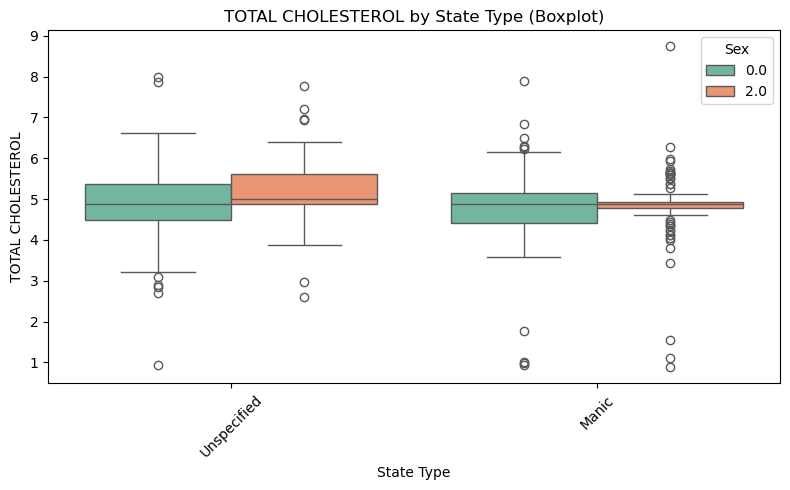

In [36]:
# Map and encode bipolar disorder states
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='State Type',plot_type='box', hue="Sex")

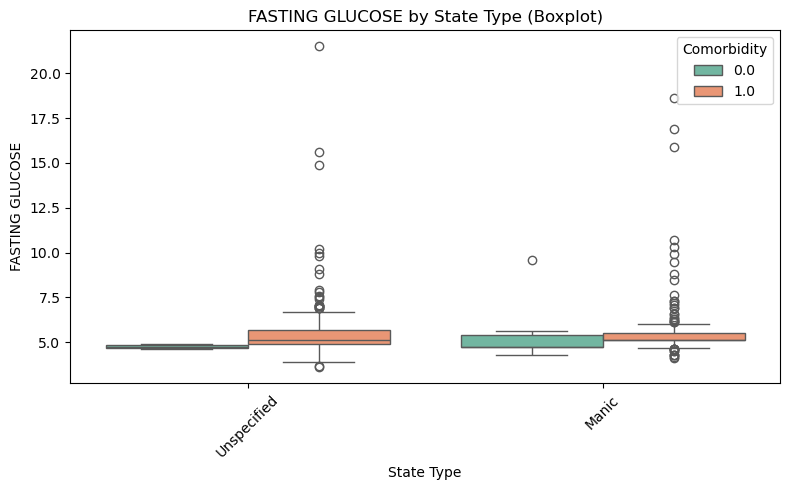

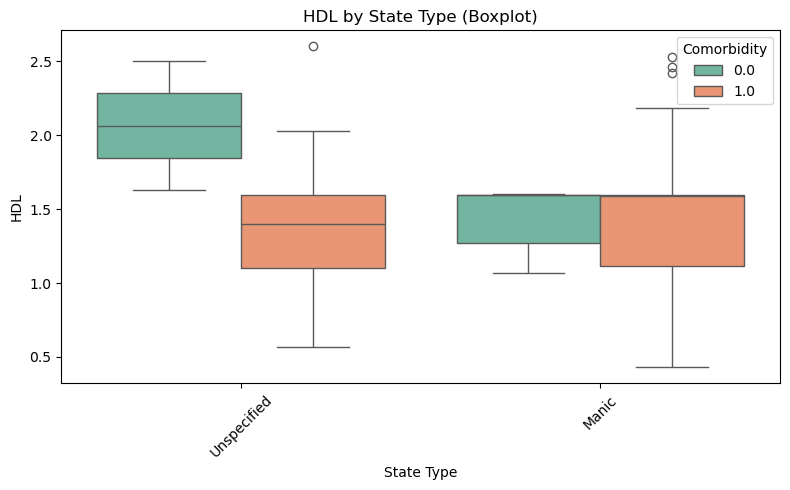

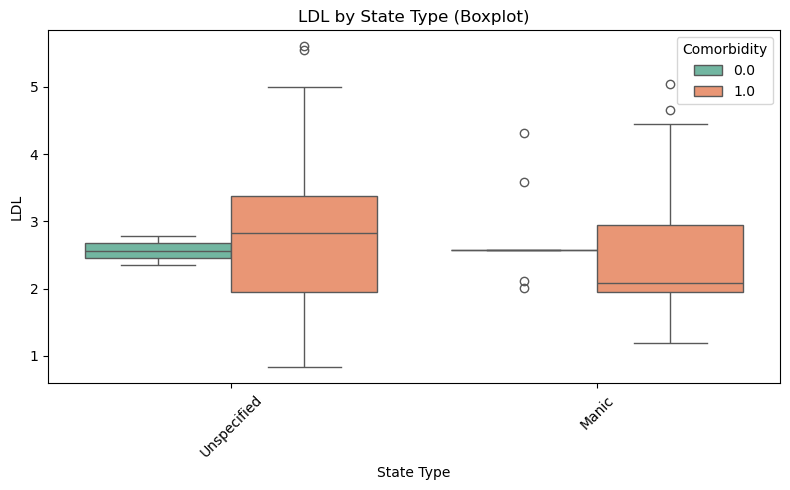

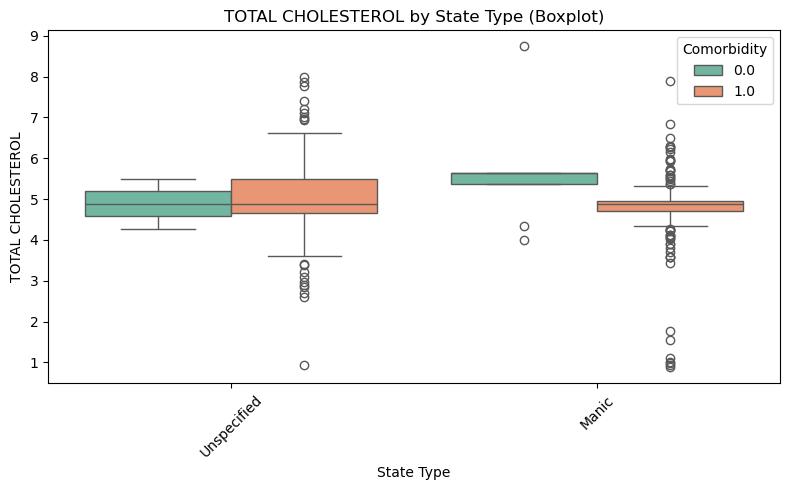

In [37]:
em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='State Type',plot_type='box', hue="Comorbidity")

In [38]:
# Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups
em.kruskal_test(df, 
             variables= ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL','Sex','Comorbidity','Age'], 
             group_col='Bipolar Disorder Type Factor')

FASTING GLUCOSE: H=1.618, p=0.4454
HDL: H=1.350, p=0.5091
LDL: H=6.024, p=0.0492
TOTAL CHOLESTEROL: H=2.237, p=0.3268
Sex: H=11.559, p=0.0031
Comorbidity: H=3.629, p=0.0568
Age: H=0.210, p=0.9002


,variable,n_groups,H_stat,p_value
0,FASTING GLUCOSE,3,1.617637,0.445384
1,HDL,3,1.350369,0.509062
2,LDL,3,6.024197,0.049188
3,TOTAL CHOLESTEROL,3,2.236710,0.326817
4,Sex,3,11.558677,0.003091
5,Comorbidity,2,3.628642,0.056793
6,Age,3,0.210166,0.900250


In [39]:
em.kruskal_test(df, 
             variables= ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL','Sex','Comorbidity','Age'], 
             group_col='State Type Factor')

FASTING GLUCOSE: H=0.682, p=0.4089
HDL: H=0.000, p=0.9822
LDL: H=4.239, p=0.0395
TOTAL CHOLESTEROL: H=1.805, p=0.1791
Sex: H=11.607, p=0.0007
Comorbidity: H=4.332, p=0.0374
Age: H=0.197, p=0.6568


,variable,n_groups,H_stat,p_value
0,FASTING GLUCOSE,2,0.681885,0.408938
1,HDL,2,0.000496,0.982225
2,LDL,2,4.239438,0.039495
3,TOTAL CHOLESTEROL,2,1.805197,0.179085
4,Sex,2,11.607160,0.000657
5,Comorbidity,2,4.332475,0.037392
6,Age,2,0.197389,0.656836


In [59]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select and standardize features
X = df[['FASTING_GLUCOSE', 'HDL', 'LDL', 'TOTAL_CHOLESTEROL', 'Age','Sex','Comorbidity']].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means, choose number of clusters, e.g., 3
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels back to DataFrame (align index if needed)
df_clusters = df.loc[X.index].copy()
df_clusters['Cluster'] = clusters
print(df_clusters['Cluster'].value_counts())


Cluster
0    164
1    147
Name: count, dtype: int64


In [60]:
import scipy.stats as stats
import pandas as pd

# Contingency table
contingency_table = pd.crosstab(df_clusters['Cluster'], df_clusters['Bipolar Disorder Type Factor'])

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)


Chi-square statistic: 6.313739814119868
Degrees of freedom: 4
P-value: 0.1769111690450765


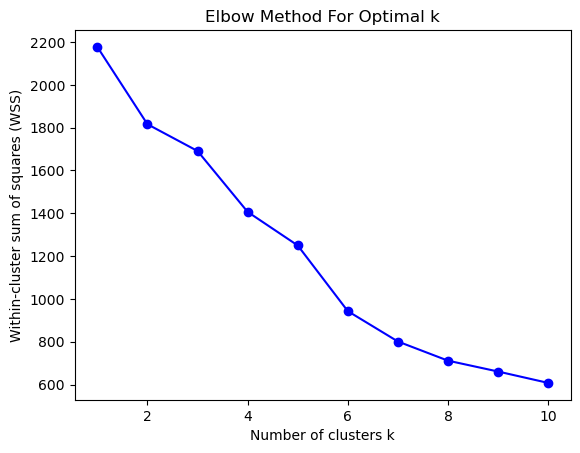

In [62]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wss.append(kmeans.inertia_)  # inertia_ 即 WSS

plt.plot(K_range, wss, 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Within-cluster sum of squares (WSS)')
plt.title('Elbow Method For Optimal k')
plt.show()


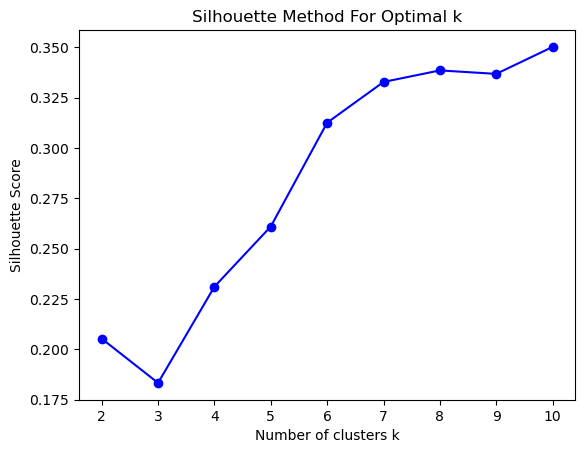

In [63]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.plot(range(2, 11), sil_scores, 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method For Optimal k')
plt.show()


In [47]:
df

,Patient_ID,PerformedDate,BD_Diagnosis_Date,BD_Code,FASTING GLUCOSE,HDL,LDL,TOTAL CHOLESTEROL,Sex,BirthYear,Age,Comorbidity,Bipolar Disorder Type,Bipolar Disorder Type Factor,Bipolar Disorder Type Num,State Type,State Type Factor,State Type Num
0,1002000000004471,2008-11-05,2008-10-15,296.7,4.60,1.920,1.300,4.090,0.0,1979.0,58.0,1.0,BipolarI_Unspecified,BipolarI_Unspecified,5,Unspecified,Unspecified,2
1,1002000000010475,2009-01-23,2009-01-21,296.4,5.40,1.810,2.020,4.450,1.0,1955.0,108.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
2,1002000000010475,2010-11-09,2009-01-21,296.4,5.14,1.592,1.948,4.878,1.0,1955.0,110.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
3,1002000000014574,2010-03-24,2009-06-19,296.4,6.90,1.240,2.710,4.470,0.0,1927.0,166.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
4,1002000000014574,2010-09-21,2009-06-19,296.4,7.30,1.278,3.188,4.242,0.0,1927.0,166.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,13001000000025709,2012-07-20,2011-07-08,296.4,5.40,2.460,2.090,4.900,0.0,1976.0,72.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
314,13001000000026019,2011-02-18,2010-07-20,296.4,6.20,1.088,3.154,4.240,1.0,1951.0,120.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
315,13001000000026019,2011-04-01,2010-07-20,296.4,5.14,1.592,1.948,4.878,1.0,1951.0,120.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
316,13001000000026019,2011-11-22,2010-07-20,296.4,6.10,1.136,5.040,1.540,1.0,1951.0,120.0,1.0,BipolarI_CurrentManic,BipolarI_CurrentManic,2,Manic,Manic,0
